# Fertilizer Recommendation: Minimal Feature Model

This notebook trains a model using only the following 6 fields:
1. **Humidity**
2. **Temperature**
4. **pH**
5. **Nitrogen (N)**
6. **Phosphorus (P)**
7. **Potassium (K)**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import pickle
import warnings

warnings.filterwarnings('ignore')

## 1. Load Data & Feature Selection

In [2]:
df = pd.read_csv('AgriSense_ML_Ready.csv')

# Select only requested columns
# Fields mapping:
# Field 1: Humidity
# Field 2: Temperature
# Field 4: pH
# Field 5: Nitrogen
# Field 6: Phosphorus
# Field 7: Potassium
minimal_features = ['humidity', 'temperature', 'ph', 'N', 'P', 'K']

X = df[minimal_features]
y = df['Fertilizer']

# Encode Target
le_fert = LabelEncoder()
y_encoded = le_fert.fit_transform(y)

print(f"Using minimal features: {minimal_features}")
print(dict(zip(range(len(le_fert.classes_)), le_fert.classes_)))
X.head()

Using minimal features: ['humidity', 'temperature', 'ph', 'N', 'P', 'K']
{0: 'Lime', 1: 'MOP', 2: 'Optimal', 3: 'TSP', 4: 'Urea'}


,humidity,temperature,ph,N,P,K
0,82.002744,20.879744,6.502985,90,42,43
1,80.319644,21.770462,7.038096,85,58,41
2,82.320763,23.004459,7.840207,60,55,44
3,80.158363,26.491096,6.980401,74,35,40
4,81.604873,20.130175,7.628473,78,42,42


## 2. Train-Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

Training set: 1760 samples
Test set: 440 samples


## 3. Modeling (Balanced Random Forest)

In [4]:
# We use 'balanced' class weights to handle minority classes like Lime
rf = RandomForestClassifier(
    n_estimators=200, 
    max_depth=15, 
    class_weight='balanced', 
    random_state=42
)

rf.fit(X_train, y_train)
print("Model trained.")

Model trained.


## 4. Final Evaluation


Final Test Accuracy: 0.9659090909090909

Classification Report (Test Set):
               precision    recall  f1-score   support

        Lime       1.00      0.62      0.77        16
         MOP       0.95      0.95      0.95        63
     Optimal       0.96      0.99      0.97       231
         TSP       1.00      0.97      0.98        31
        Urea       0.98      0.97      0.97        99

    accuracy                           0.97       440
   macro avg       0.98      0.90      0.93       440
weighted avg       0.97      0.97      0.96       440



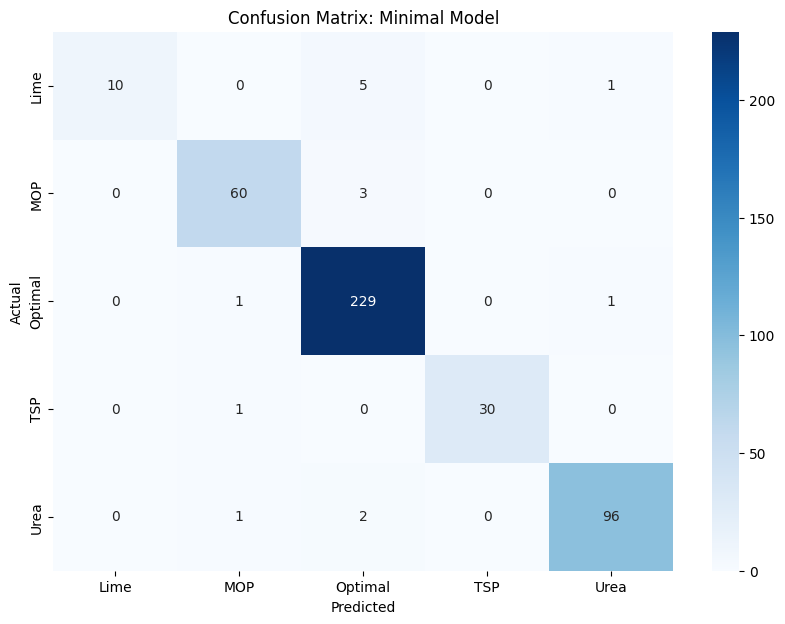

In [5]:
y_pred = rf.predict(X_test)
print("\nFinal Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report (Test Set):\n", classification_report(y_test, y_pred, target_names=le_fert.classes_))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_fert.classes_, yticklabels=le_fert.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Minimal Model')
plt.show()

## 5. Save the Minimal Model

In [6]:
with open('agrisense_rf_minimal.pkl', 'wb') as f:
    pickle.dump({
        'model': rf, 
        'label_encoder': le_fert, 
        'features': minimal_features
    }, f)
print("Minimal model saved to 'agrisense_rf_minimal.pkl'.")

Minimal model saved to 'agrisense_rf_minimal.pkl'.
